In [5]:
# [cell 1] Установка библиотек (если не установлены)
!pip install faker pandas networkx matplotlib

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 1.8 MB/s eta 0:00:01
   ------------------------------------ --- 1.8/2.0 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 2.6 MB/s  0:00:01
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ------------------------- -------------- 1.3/2.1 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 4.4 MB/s  0:00:00

   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [netwo

In [6]:
# [cell 2] Импорт библиотек
import pandas as pd
import random
import json
from faker import Faker
from datetime import datetime, timedelta
import networkx as nx
import matplotlib.pyplot as plt

=== Владельцы ===


,owner_id,full_name,passport_series,passport_number,passport_issued_by,address,phone,email
0,1,Козлова Ирина Ефимовна,2824,126225,АО «Чернова Ершов»,"г. Артем, алл. Лесозаводская, д. 983, 379402",8 542 351 16 15,ernest_40@example.net
1,2,Владилен Матвеевич Федоров,5506,356787,Сафонов Лимитед,"клх Братск, бул. Курский, д. 2, 164752",8 534 192 8327,opotapov@example.net
2,3,Зимина Лидия Аркадьевна,4657,246316,ОАО «Голубев Калашникова»,"к. Бологое, пер. Островского, д. 77, 242388",+79696532871,samolovavalerija@example.org
3,4,Вишнякова Наталья Эльдаровна,2679,809570,НПО «Фадеев»,"д. Александров Гай, бул. Донской, д. 6 стр. 34...",+78932528809,selivan_01@example.com
4,5,Ксения Егоровна Павлова,9935,191161,ЗАО «Фомичева Яковлев»,"ст. Боровск, ш. Кедровое, д. 97 стр. 94, 383465",8 (871) 331-50-98,haritonpoljakov@example.org


=== Объекты недвижимости ===


,property_id,address,property_type,area,rooms,floor,build_year,cadastral_number,owner_info
0,1,"клх Муравленко, пер. Тельмана, д. 2/1 стр. 223...",Коммерческое,77.1,NaN,20,2014,64:80:567574:919,"[{""owner_id"": 287, ""share"": 1.0}]"
1,2,"ст. Радужный, ул. Сплавная, д. 801, 902517",Дом,66.7,3.0,25,2016,72:90:350867:282,"[{""owner_id"": 244, ""share"": 1.0}]"
2,3,"клх Хужир, алл. Привольная, д. 8 стр. 5/4, 268319",Квартира,68.9,NaN,18,1960,27:29:342495:393,"[{""owner_id"": 147, ""share"": 1.0}]"
3,4,"п. Асбест, ул. Терешковой, д. 9/2, 287339",Квартира,94.7,NaN,18,2009,63:17:316881:853,"[{""owner_id"": 110, ""share"": 1.0}]"
4,5,"к. Южно-Сахалинск, ш. Придорожное, д. 776 стр....",Коммерческое,23.5,NaN,16,1950,55:48:890075:400,"[{""owner_id"": 300, ""share"": 1.0}]"


=== Ценовой архив ===


,price_history_id,property_id,change_date,new_price
0,1,1,2015-01-01,13236533
1,2,1,2025-11-03,16225887
2,3,2,2015-01-01,5765989
3,4,3,2015-01-01,2842766
4,5,3,2020-07-25,3370075


=== Сделки ===


,transaction_id,date,property_id,seller_id,buyer_id,price,notary
0,1,2024-11-28,820,57,284,1092334,Кулагина Алевтина Яковлевна
1,2,2024-07-08,792,244,250,25559703,Меркушев Бажен Гаврилович
2,3,2022-10-21,1745,215,251,12650911,г-жа Зиновьева Милица Игоревна
3,4,2026-05-27,1245,22,211,14004046,Порфирий Фомич Семенов
4,5,2025-02-10,778,179,80,26921257,Ярослав Тарасович Калинин


CSV файлы сохранены: owners.csv, properties.csv, price_history.csv, transactions.csv


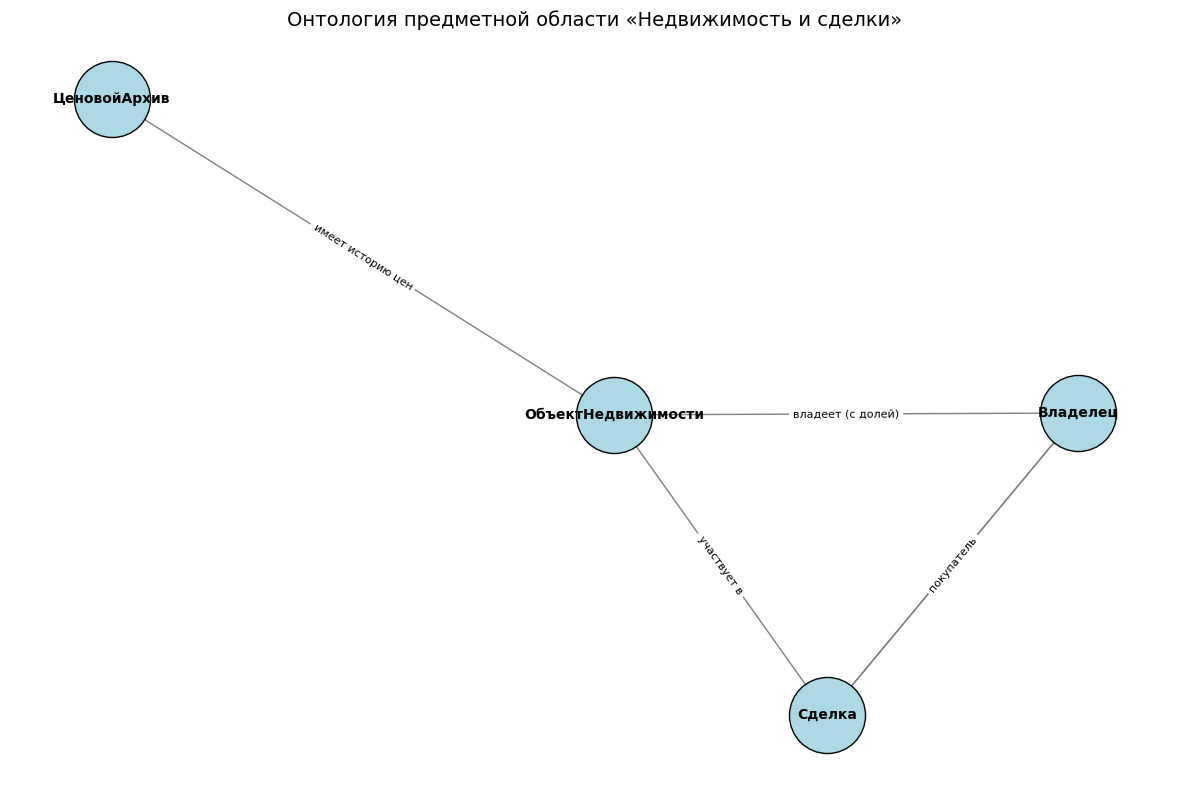


=== Структура онтологии ===

Класс: Владелец
  Атрибуты: owner_id, full_name, passport_series, passport_number, address, phone, email
  Связи:
    -> ОбъектНедвижимости : владеет (с долей)
    -> Сделка : продавец
    <- Сделка : покупатель

Класс: ОбъектНедвижимости
  Атрибуты: property_id, address, property_type, area, rooms, floor, build_year, cadastral_number, owner_info(JSON)
  Связи:
    -> ЦеновойАрхив : имеет историю цен
    -> Сделка : участвует в
    <- Владелец : владеет (с долей)

Класс: Сделка
  Атрибуты: transaction_id, date, price, notary
  Связи:
    -> Владелец : покупатель
    <- Владелец : продавец
    <- ОбъектНедвижимости : участвует в

Класс: ЦеновойАрхив
  Атрибуты: price_history_id, change_date, new_price
  Связи:
    <- ОбъектНедвижимости : имеет историю цен


In [7]:
# [cell 3] Инициализация генератора
fake = Faker('ru_RU')
Faker.seed(42)
random.seed(42)

# [cell 4] Генерация сущностей
# 1. Владельцы
def generate_owners(n: int) -> pd.DataFrame:
    owners = []
    for i in range(1, n + 1):
        passport_series = random.randint(1000, 9999)
        passport_number = random.randint(100000, 999999)
        owners.append({
            'owner_id': i,
            'full_name': fake.name(),
            'passport_series': passport_series,
            'passport_number': passport_number,
            'passport_issued_by': fake.company(),  # кем выдан
            'address': fake.address().replace('\n', ', '),
            'phone': fake.phone_number(),
            'email': fake.email()
        })
    return pd.DataFrame(owners)

# 2. Объекты недвижимости
def generate_properties(n: int, owner_ids: list) -> pd.DataFrame:
    property_types = ['Квартира', 'Дом', 'Коммерческое']
    properties = []
    for i in range(1, n + 1):
        # Случайное количество владельцев (1-3) для долевой собственности
        num_owners = random.choices([1, 2, 3], weights=[0.7, 0.2, 0.1])[0]
        selected_owners = random.sample(owner_ids, num_owners)
        # Доли (в сумме 1.0)
        shares = []
        remaining = 1.0
        for j in range(num_owners - 1):
            share = round(random.uniform(0.1, remaining - 0.1), 2)
            shares.append(share)
            remaining -= share
        shares.append(round(remaining, 2))
        # Формируем JSON для владельцев и долей
        owners_with_shares = [
            {'owner_id': selected_owners[k], 'share': shares[k]}
            for k in range(num_owners)
        ]
        
        properties.append({
            'property_id': i,
            'address': fake.address().replace('\n', ', '),
            'property_type': random.choice(property_types),
            'area': round(random.uniform(20.0, 200.0), 1),
            'rooms': random.randint(1, 5) if random.choice([True, False]) else None,
            'floor': random.randint(1, 25),
            'build_year': random.randint(1950, 2024),
            'cadastral_number': f"{random.randint(10, 99)}:{random.randint(10, 99)}:{random.randint(100000, 999999)}:{random.randint(1, 999)}",
            'owner_info': json.dumps(owners_with_shares, ensure_ascii=False)  # JSON строка
        })
    return pd.DataFrame(properties)

# 3. Ценовой архив
def generate_price_history(properties_df: pd.DataFrame, avg_records: int = 2) -> pd.DataFrame:
    history = []
    record_id = 1
    start_date = datetime(2015, 1, 1)
    end_date = datetime.now()
    
    for _, prop in properties_df.iterrows():
        prop_id = prop['property_id']
        base_price = random.randint(1_000_000, 20_000_000)  # начальная цена
        
        # Количество изменений цены
        num_changes = random.choices([0, 1, 2, 3], weights=[0.3, 0.4, 0.2, 0.1])[0]
        change_dates = sorted([fake.date_between(start_date=start_date, end_date=end_date) 
                               for _ in range(num_changes)])
        
        # Цены с динамикой (рост или падение)
        all_dates = [start_date.date()] + change_dates
        all_prices = [base_price]
        for _ in range(num_changes):
            change = random.uniform(-0.15, 0.25)  # от -15% до +25%
            new_price = int(all_prices[-1] * (1 + change))
            all_prices.append(new_price)
        
        for i in range(len(all_dates)):
            history.append({
                'price_history_id': record_id,
                'property_id': prop_id,
                'change_date': all_dates[i],
                'new_price': all_prices[i]
            })
            record_id += 1
    return pd.DataFrame(history)

# 4. Сделки купли-продажи
def generate_transactions(n: int, properties_df: pd.DataFrame, owners_df: pd.DataFrame) -> pd.DataFrame:
    transactions = []
    for i in range(1, n + 1):
        property_row = properties_df.sample(1).iloc[0]
        property_id = property_row['property_id']
        # Продавец – один из текущих владельцев
        current_owners = json.loads(property_row['owner_info'])
        seller_id = random.choice(current_owners)['owner_id']
        # Покупатель – другой владелец (из списка всех, кроме продавца)
        other_owners = owners_df[owners_df['owner_id'] != seller_id]['owner_id'].tolist()
        if not other_owners:
            other_owners = owners_df['owner_id'].tolist()
        buyer_id = random.choice(other_owners)
        
        transaction_date = fake.date_between(start_date='-5y', end_date='today')
        price = random.randint(500_000, 30_000_000)
        
        transactions.append({
            'transaction_id': i,
            'date': transaction_date,
            'property_id': property_id,
            'seller_id': seller_id,
            'buyer_id': buyer_id,
            'price': price,
            'notary': fake.name()
        })
    return pd.DataFrame(transactions)

# [cell 5] Параметры объёмов данных
N_OWNERS = 300
N_PROPERTIES = 2000
N_TRANSACTIONS = 150

# [cell 6] Генерация DataFrame'ов
owners_df = generate_owners(N_OWNERS)
properties_df = generate_properties(N_PROPERTIES, owners_df['owner_id'].tolist())
price_history_df = generate_price_history(properties_df, avg_records=2)
transactions_df = generate_transactions(N_TRANSACTIONS, properties_df, owners_df)

# [cell 7] Просмотр первых записей
print("=== Владельцы ===")
display(owners_df.head())

print("=== Объекты недвижимости ===")
display(properties_df.head())

print("=== Ценовой архив ===")
display(price_history_df.head())

print("=== Сделки ===")
display(transactions_df.head())

# [cell 8] Сохранение в CSV
owners_df.to_csv('owners.csv', index=False)
properties_df.to_csv('properties.csv', index=False)
price_history_df.to_csv('price_history.csv', index=False)
transactions_df.to_csv('transactions.csv', index=False)

print("CSV файлы сохранены: owners.csv, properties.csv, price_history.csv, transactions.csv")

# [cell 9] Построение онтологии и онтографа
# Создание графа
G = nx.DiGraph()

# Добавление классов
classes = ['Владелец', 'ОбъектНедвижимости', 'Сделка', 'ЦеновойАрхив']
G.add_nodes_from(classes, type='class')

# Добавление свойств и связей
# Владелец -> ОбъектНедвижимости (владеет с долей)
G.add_edge('Владелец', 'ОбъектНедвижимости', label='владеет (с долей)')
# ОбъектНедвижимости -> ЦеновойАрхив (имеет историю цен)
G.add_edge('ОбъектНедвижимости', 'ЦеновойАрхив', label='имеет историю цен')
# Сделка связывает продавец(Владелец) -> Объект -> покупатель(Владелец)
G.add_edge('Владелец', 'Сделка', label='продавец')
G.add_edge('ОбъектНедвижимости', 'Сделка', label='участвует в')
G.add_edge('Сделка', 'Владелец', label='покупатель')

# Атрибуты классов
attributes = {
    'Владелец': ['owner_id', 'full_name', 'passport_series', 'passport_number', 'address', 'phone', 'email'],
    'ОбъектНедвижимости': ['property_id', 'address', 'property_type', 'area', 'rooms', 'floor', 'build_year', 'cadastral_number', 'owner_info(JSON)'],
    'Сделка': ['transaction_id', 'date', 'price', 'notary'],
    'ЦеновойАрхив': ['price_history_id', 'change_date', 'new_price']
}

for node, attrs in attributes.items():
    G.nodes[node]['attributes'] = ', '.join(attrs)

# Визуализация онтографа
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=1.5)
# Рисуем узлы
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
# Рисуем рёбра с подписями
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray')
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Онтология предметной области «Недвижимость и сделки»", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# [cell 10] Вывод информации об онтологии
print("\n=== Структура онтологии ===")
for node in G.nodes():
    print(f"\nКласс: {node}")
    print(f"  Атрибуты: {G.nodes[node]['attributes']}")
    print("  Связи:")
    for pred, succ, data in G.out_edges(node, data=True):
        print(f"    -> {succ} : {data['label']}")
    for pred, succ, data in G.in_edges(node, data=True):
        print(f"    <- {pred} : {data['label']}")